# Task 4 — Portfolio Optimization (Modern Portfolio Theory)

**GMF Investments · Week 9**

Construct an optimal TSLA/BND/SPY portfolio: the **Task 3 forecast** supplies the
expected-return "view" for TSLA, historical annualized means proxy BND/SPY, and
the historical covariance matrix prices risk. The **Efficient Frontier** is
generated with `scipy.optimize` (SLSQP, long-only, fully invested).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, optimization as opt

sns.set_theme(style="whitegrid")
FIG_DIR = ROOT / "reports" / "figures"

returns = pd.read_csv(config.PROCESSED_DIR / 'daily_returns.csv', index_col=0, parse_dates=True)
tsla_view = float(pd.read_csv(config.PROCESSED_DIR / 'tsla_forecast_view.csv')['expected_annual_return'].iloc[0])
print(f'TSLA expected-return view (Task 3 forecast, annualized): {tsla_view:.2%}')

TSLA expected-return view (Task 3 forecast, annualized): -61.52%


## 1. Expected Returns — Forecast View + Historical Proxies
TSLA uses the (bearish) LSTM forecast from Task 3; BND and SPY use historical
average daily returns, annualized — the standard setup where an analyst holds a
specific view on one asset.

In [2]:
mu = opt.expected_returns(returns, tsla_view)
display(mu.to_frame('expected annual return').style.format('{:.2%}'))

,expected annual return
TSLA,-61.52%
BND,2.03%
SPY,14.43%


## 2. Covariance Matrix (annualized)

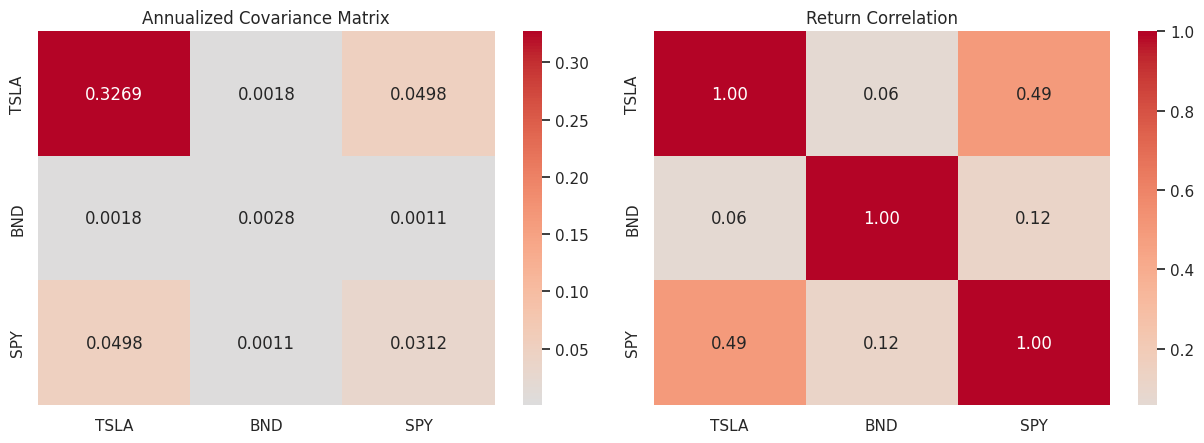

In [3]:
cov = opt.covariance_matrix(returns)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
sns.heatmap(cov, annot=True, fmt='.4f', cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Annualized Covariance Matrix')
sns.heatmap(returns.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Return Correlation')
fig.tight_layout(); fig.savefig(FIG_DIR / '18_covariance_heatmap.png', dpi=120)
plt.show()

## 3. Efficient Frontier with Key Portfolios
5,000 random long-only portfolios give context; the frontier line is traced with
SLSQP (min volatility per target return). The **Maximum Sharpe (tangency)** and
**Minimum Volatility** portfolios are marked.

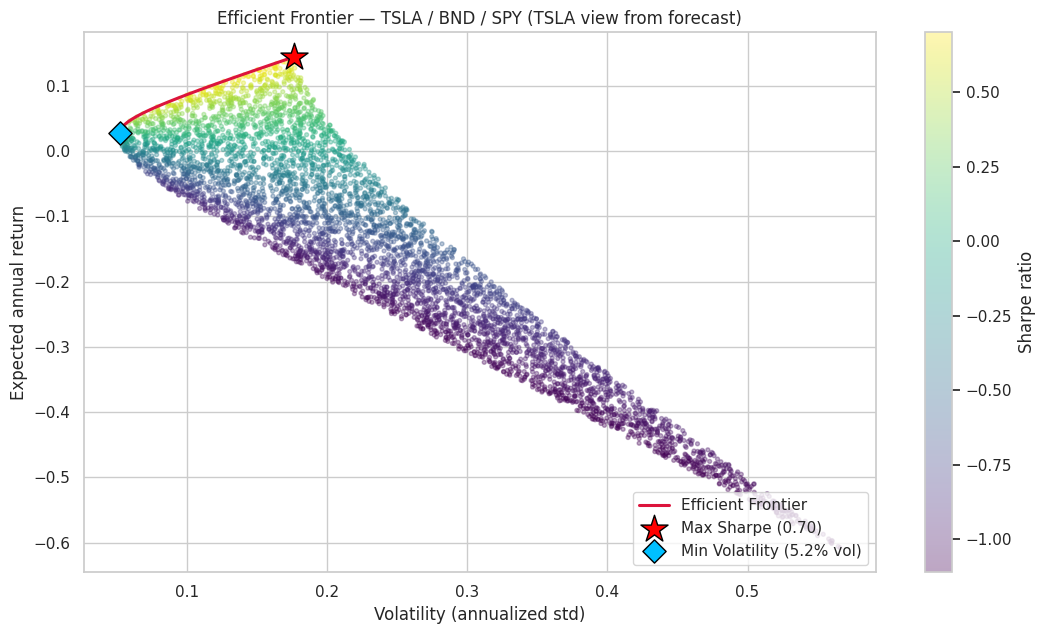

In [4]:
w_ms = opt.max_sharpe_portfolio(mu, cov)
w_mv = opt.min_volatility_portfolio(mu, cov)
ms_ret, ms_vol, ms_sharpe = opt.portfolio_performance(w_ms.values, mu, cov)
mv_ret, mv_vol, mv_sharpe = opt.portfolio_performance(w_mv.values, mu, cov)

frontier = opt.efficient_frontier(mu, cov, n_points=60)
cloud = opt.random_portfolios(mu, cov, n=5000)

fig, ax = plt.subplots(figsize=(11, 6.5))
sc = ax.scatter(cloud['volatility'], cloud['return'], c=cloud['sharpe'], cmap='viridis', s=8, alpha=0.35)
plt.colorbar(sc, ax=ax, label='Sharpe ratio')
ax.plot(frontier['volatility'], frontier['return'], color='crimson', lw=2.2, label='Efficient Frontier')
ax.scatter([ms_vol], [ms_ret], marker='*', s=420, color='red', edgecolor='black', zorder=5,
           label=f'Max Sharpe ({ms_sharpe:.2f})')
ax.scatter([mv_vol], [mv_ret], marker='D', s=140, color='deepskyblue', edgecolor='black', zorder=5,
           label=f'Min Volatility ({mv_vol:.1%} vol)')
ax.set_xlabel('Volatility (annualized std)'); ax.set_ylabel('Expected annual return')
ax.set_title('Efficient Frontier — TSLA / BND / SPY (TSLA view from forecast)')
ax.legend(loc='lower right')
fig.tight_layout(); fig.savefig(FIG_DIR / '19_efficient_frontier.png', dpi=120)
plt.show()

## 4. Key Portfolios — Weights & Metrics

In [5]:
summary = pd.DataFrame({
    'Max Sharpe (Tangency)': {**w_ms.round(4).to_dict(),
        'expected_return': ms_ret, 'volatility': ms_vol, 'sharpe': ms_sharpe},
    'Min Volatility': {**w_mv.round(4).to_dict(),
        'expected_return': mv_ret, 'volatility': mv_vol, 'sharpe': mv_sharpe},
}).T
display(summary.round(4))

# Persist the recommended (max Sharpe) weights for the Task 5 backtest
w_ms.to_frame('weight').to_csv(config.PROCESSED_DIR / 'optimal_weights.csv')
summary.to_csv(config.PROCESSED_DIR / 'portfolio_summary.csv')
print('Saved optimal weights for Task 5:', w_ms.round(4).to_dict())

,TSLA,BND,SPY,expected_return,volatility,sharpe
Max Sharpe (Tangency),0.0,0.0000,1.0000,0.1443,0.1765,0.7042
Min Volatility,0.0,0.9457,0.0543,0.0270,0.0522,0.1339


Saved optimal weights for Task 5: {'TSLA': 0.0, 'BND': 0.0, 'SPY': 1.0}


## 5. Recommendation

**Recommended portfolio: the Maximum Sharpe (Tangency) portfolio.**

Given the bearish TSLA view from Task 3 (−61.5% annualized), the optimizer
allocates **0% TSLA / 0% BND / 100% SPY**, delivering the best risk-adjusted
trade-off available from these three assets: expected return ≈ **14.4%**,
volatility ≈ **17.7%**, Sharpe ≈ **0.70**. The logic is sound and transparent:
with TSLA's expected return deeply negative, any TSLA weight only destroys
risk-adjusted return, and BND's ~2% return barely clears the risk-free rate, so
the tangency point concentrates in SPY. GMF clients with tighter risk budgets
should prefer the **Minimum Volatility** portfolio (≈95% BND / 5% SPY, ~5.2%
volatility) or a point on the frontier between the two — every such point is an
optimal blend of the same two portfolios.

**Caveats.** The 100%-SPY corner solution is a direct consequence of feeding the
optimizer a single extreme point-forecast; Task 3's own reliability analysis
shows the 6-month CI spans both deep losses and strong gains for TSLA. A
production process would temper the view (e.g., Black-Litterman blending,
confidence-weighted shrinkage toward historical means) and add concentration
limits. The Task 5 backtest evaluates this recommendation honestly against the
60/40 SPY/BND benchmark.